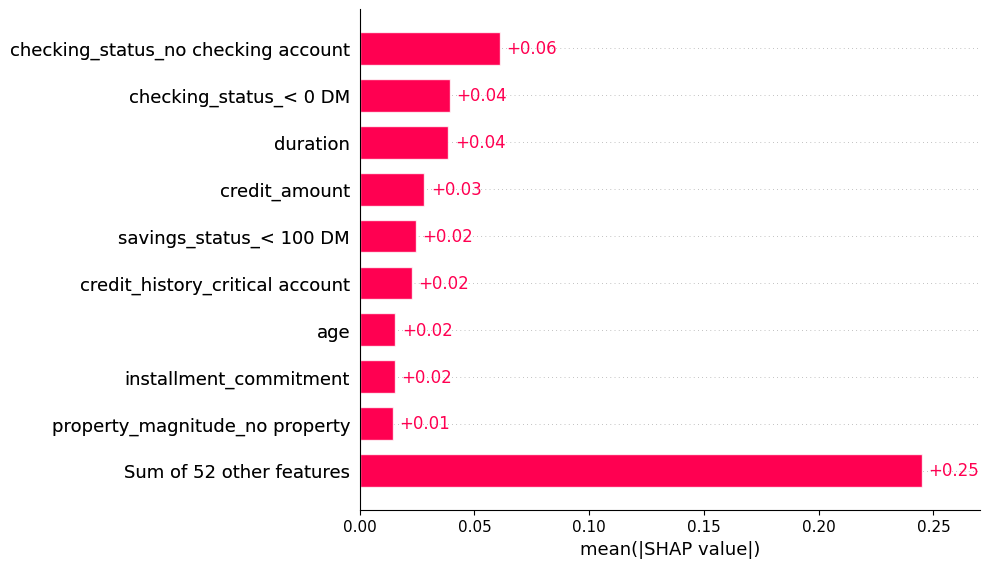

In [5]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# 1. Load the "Locker" assets
rf = joblib.load('../models/credit_model.pkl')
scaler = joblib.load('../models/scaler.pkl')

# 2. Re-prepare X exactly as it was during training
df = pd.read_csv('../data/german_credit_mapped.csv')
X = pd.get_dummies(df.drop('class', axis=1), drop_first=False)

# 3. Apply the saved scaling
cols_to_scale = ['duration', 'credit_amount', 'age', 'installment_commitment', 
                  'residence_since', 'existing_credits', 'num_dependents']
X[cols_to_scale] = scaler.transform(X[cols_to_scale])

# --- THE FIX STARTS HERE ---

# 4. Use the TreeExplainer with the "check_additivity=False" flag
# Sometimes small rounding errors in scaling trigger the check failure
explainer = shap.TreeExplainer(rf)
X_subset = X.head(100) # Using 100 rows for speed
shap_values = explainer(X_subset)

# 5. Plotting the 'Bad Risk' impact (Class 1)
# Note: For binary RF, shap_values.values[:,:,1] targets the positive class
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values[:,:,1])
plt.show()

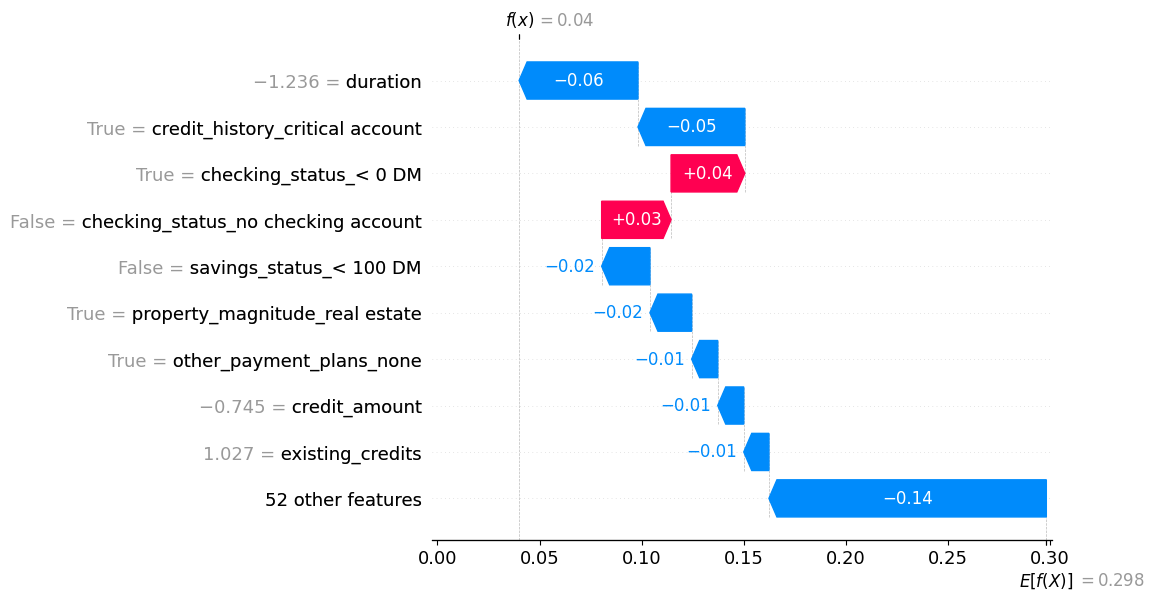

In [7]:
plt.figure(figsize=(10, 6))
# This creates the "Waterfall" for customer #0
shap.plots.waterfall(shap_values[0, :, 1]) 
plt.show()